In [1]:
!wget -q https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -q ml-100k.zip
print("Data ready!")

Data ready!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.sparse.linalg import svds
from scipy.sparse import csr_matrix
import warnings
import json
import pickle
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All imports successful!")

All imports successful!


In [3]:
ratings = pd.read_csv('ml-100k/u.data', sep='\t',
                      names=['user_id', 'movie_id', 'rating', 'timestamp'])

movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1',
                     names=['movie_id', 'title', 'release_date', 'video_release',
                            'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation',
                            'Childrens', 'Comedy', 'Crime', 'Documentary', 'Drama',
                            'Fantasy', 'Film_Noir', 'Horror', 'Musical', 'Mystery',
                            'Romance', 'Sci_Fi', 'Thriller', 'War', 'Western'])

genre_cols = ['Action', 'Adventure', 'Animation', 'Childrens', 'Comedy',
              'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film_Noir',
              'Horror', 'Musical', 'Mystery', 'Romance', 'Sci_Fi',
              'Thriller', 'War', 'Western']

movies['genres'] = movies[genre_cols].apply(
    lambda row: ' '.join([g for g in genre_cols if row[g] == 1]), axis=1)

print(f"Ratings: {ratings.shape}")
print(f"Movies:  {movies.shape}")
print(f"\nSample genre strings:")
print(movies[['title', 'genres']].head(5))

Ratings: (100000, 4)
Movies:  (1682, 25)

Sample genre strings:
               title                      genres
0   Toy Story (1995)  Animation Childrens Comedy
1   GoldenEye (1995)   Action Adventure Thriller
2  Four Rooms (1995)                    Thriller
3  Get Shorty (1995)         Action Comedy Drama
4     Copycat (1995)        Crime Drama Thriller


In [4]:
# Build user-movie matrix
user_movie_matrix = ratings.pivot_table(
    index='user_id', columns='movie_id', values='rating'
).fillna(0)

print(f"User-movie matrix shape: {user_movie_matrix.shape}")

# Normalize by subtracting each user's mean rating
matrix = user_movie_matrix.values
user_ratings_mean = np.mean(matrix, axis=1)
matrix_normalized = matrix - user_ratings_mean.reshape(-1, 1)

# Apply SVD
sparse_matrix = csr_matrix(matrix_normalized)
U, sigma, Vt = svds(sparse_matrix, k=50)
sigma = np.diag(sigma)

# Reconstruct predicted ratings matrix
predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)
predicted_df = pd.DataFrame(
    predicted_ratings,
    columns=user_movie_matrix.columns,
    index=user_movie_matrix.index
)

print("SVD completed successfully!")
print(f"Predicted ratings matrix shape: {predicted_df.shape}")

def get_collaborative_recommendations(user_id, n=10):
    user_row = predicted_df.loc[user_id]
    already_rated = user_movie_matrix.loc[user_id]
    already_rated = already_rated[already_rated > 0].index.tolist()
    recommendations = user_row.drop(already_rated).sort_values(ascending=False).head(n)
    rec_movies = movies[movies['movie_id'].isin(recommendations.index)][['movie_id', 'title', 'genres']]
    rec_movies['predicted_rating'] = rec_movies['movie_id'].map(recommendations)
    return rec_movies.sort_values('predicted_rating', ascending=False)

# Test it
print("\nTop 10 collaborative recommendations for user 1:")
print(get_collaborative_recommendations(1))

User-movie matrix shape: (943, 1682)
SVD completed successfully!
Predicted ratings matrix shape: (943, 1682)

Top 10 collaborative recommendations for user 1:
     movie_id                                   title  \
422       423       E.T. the Extra-Terrestrial (1982)   
402       403                           Batman (1989)   
731       732                             Dave (1993)   
356       357  One Flew Over the Cuckoo's Nest (1975)   
384       385                        True Lies (1994)   
302       303                      Ulee's Gold (1997)   
469       470                        Tombstone (1993)   
366       367                         Clueless (1995)   
581       582                       Piano, The (1993)   
317       318                 Schindler's List (1993)   

                              genres  predicted_rating  
422   Childrens Drama Fantasy Sci_Fi          3.509642  
402     Action Adventure Crime Drama          3.097894  
731                   Comedy Romance      

In [5]:
# Build TF-IDF matrix on genre strings
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres'].fillna(''))

# Compute cosine similarity between all movies
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Cosine similarity matrix shape: {cosine_sim.shape}")

# Map movie titles to indices
movie_indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

def get_content_recommendations(title, n=10):
    if title not in movie_indices:
        return pd.DataFrame()
    idx = movie_indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    movie_idxs = [i[0] for i in sim_scores]
    result = movies.iloc[movie_idxs][['movie_id', 'title', 'genres']].copy()
    result['similarity_score'] = [i[1] for i in sim_scores]
    return result

# Test it
print("\nContent-based recommendations similar to Toy Story (1995):")
print(get_content_recommendations('Toy Story (1995)'))

TF-IDF matrix shape: (1682, 18)
Cosine similarity matrix shape: (1682, 1682)

Content-based recommendations similar to Toy Story (1995):
      movie_id                                              title  \
421        422             Aladdin and the King of Thieves (1996)   
101        102                             Aristocats, The (1970)   
403        404                                   Pinocchio (1940)   
624        625                     Sword in the Stone, The (1963)   
945        946                      Fox and the Hound, The (1981)   
968        969        Winnie the Pooh and the Blustery Day (1968)   
1065      1066                                       Balto (1995)   
1077      1078                            Oliver & Company (1988)   
1408      1409                          Swan Princess, The (1994)   
1411      1412  Land Before Time III: The Time of the Great Gi...   

                          genres  similarity_score  
421   Animation Childrens Comedy          1.000000

In [6]:
def get_hybrid_recommendations(user_id, mood, n=8):

    mood_genre_map = {
        'anxious':   ['Comedy', 'Animation', 'Childrens', 'Musical'],
        'sad':       ['Comedy', 'Romance', 'Animation'],
        'angry':     ['Documentary', 'Comedy', 'Musical'],
        'lonely':    ['Drama', 'Romance', 'Comedy'],
        'stressed':  ['Animation', 'Childrens', 'Musical', 'Comedy'],
        'happy':     ['Action', 'Adventure', 'Sci_Fi', 'Thriller'],
        'neutral':   ['Drama', 'Mystery', 'Thriller'],
        'depressed': ['Comedy', 'Animation', 'Musical', 'Childrens']
    }

    target_genres = mood_genre_map.get(mood, ['Drama', 'Comedy'])

    # Step 1 - get collaborative scores for this user
    user_row = predicted_df.loc[user_id]
    already_rated = user_movie_matrix.loc[user_id]
    already_rated = already_rated[already_rated > 0].index.tolist()
    collab_scores = user_row.drop(already_rated).reset_index()
    collab_scores.columns = ['movie_id', 'collab_score']

    # Step 2 - merge with movie info
    merged = collab_scores.merge(movies[['movie_id', 'title', 'genres']], on='movie_id')

    # Step 3 - mood filter: keep only movies matching target genres
    def matches_mood(genre_str):
        return any(g in genre_str for g in target_genres)

    mood_filtered = merged[merged['genres'].apply(matches_mood)].copy()

    # Step 4 - normalize collab score to 0-1
    min_s = mood_filtered['collab_score'].min()
    max_s = mood_filtered['collab_score'].max()
    mood_filtered['collab_norm'] = (mood_filtered['collab_score'] - min_s) / (max_s - min_s + 1e-9)

    # Step 5 - content similarity score (avg similarity to top genre movies)
    mood_filtered['content_score'] = mood_filtered['genres'].apply(
        lambda g: sum(1 for genre in target_genres if genre in g) / len(target_genres)
    )

    # Step 6 - hybrid score (60% collab, 40% content)
    mood_filtered['hybrid_score'] = (0.6 * mood_filtered['collab_norm'] +
                                      0.4 * mood_filtered['content_score'])

    result = mood_filtered.sort_values('hybrid_score', ascending=False).head(n)
    return result[['movie_id', 'title', 'genres', 'hybrid_score']]

# Test it
print("CINEHEALTH HYBRID RECOMMENDATIONS")
print("User 1 | Mood: anxious")
print("=" * 60)
recs = get_hybrid_recommendations(user_id=1, mood='anxious')
print(recs.to_string(index=False))

print("\nUser 1 | Mood: lonely")
print("=" * 60)
recs2 = get_hybrid_recommendations(user_id=1, mood='lonely')
print(recs2.to_string(index=False))

CINEHEALTH HYBRID RECOMMENDATIONS
User 1 | Mood: anxious
 movie_id                             title                                       genres  hybrid_score
      423 E.T. the Extra-Terrestrial (1982)               Childrens Drama Fantasy Sci_Fi      0.700000
      432                   Fantasia (1940)                  Animation Childrens Musical      0.683620
      993                   Hercules (1997) Adventure Animation Childrens Comedy Musical      0.654889
      732                       Dave (1993)                               Comedy Romance      0.631007
      385                  True Lies (1994)              Action Adventure Comedy Romance      0.584168
      408             Close Shave, A (1995)                    Animation Comedy Thriller      0.578107
      367                   Clueless (1995)                                       Comedy      0.561986
      418                 Cinderella (1950)                  Animation Childrens Musical      0.560787

User 1 | Mood: 

In [7]:
# Build features for popularity prediction
movie_stats = ratings.groupby('movie_id').agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    rating_std=('rating', 'std')
).reset_index().fillna(0)

# Merge with movie metadata
movie_features = movie_stats.merge(movies[['movie_id'] + genre_cols], on='movie_id')

# Extract release year as a feature
movies['year'] = movies['release_date'].str.extract(r'(\d{4})').astype(float).fillna(1995)
movie_features = movie_features.merge(movies[['movie_id', 'year']], on='movie_id')

# Target: popularity score = normalized rating count weighted by avg rating
movie_features['popularity_score'] = (
    movie_features['rating_count'] * movie_features['avg_rating']
) / movie_features['rating_count'].max()

# Features and target
feature_cols = genre_cols + ['avg_rating', 'rating_std', 'year']
X = movie_features[feature_cols]
y = movie_features['popularity_score']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=" * 50)
print("POPULARITY PREDICTION MODEL — RESULTS")
print("=" * 50)
print(f"Model     : Random Forest (100 trees)")
print(f"RMSE      : {rmse:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"R² Score  : {r2:.4f}")
print("=" * 50)

POPULARITY PREDICTION MODEL — RESULTS
Model     : Random Forest (100 trees)
RMSE      : 0.4029
MAE       : 0.2298
R² Score  : 0.4969


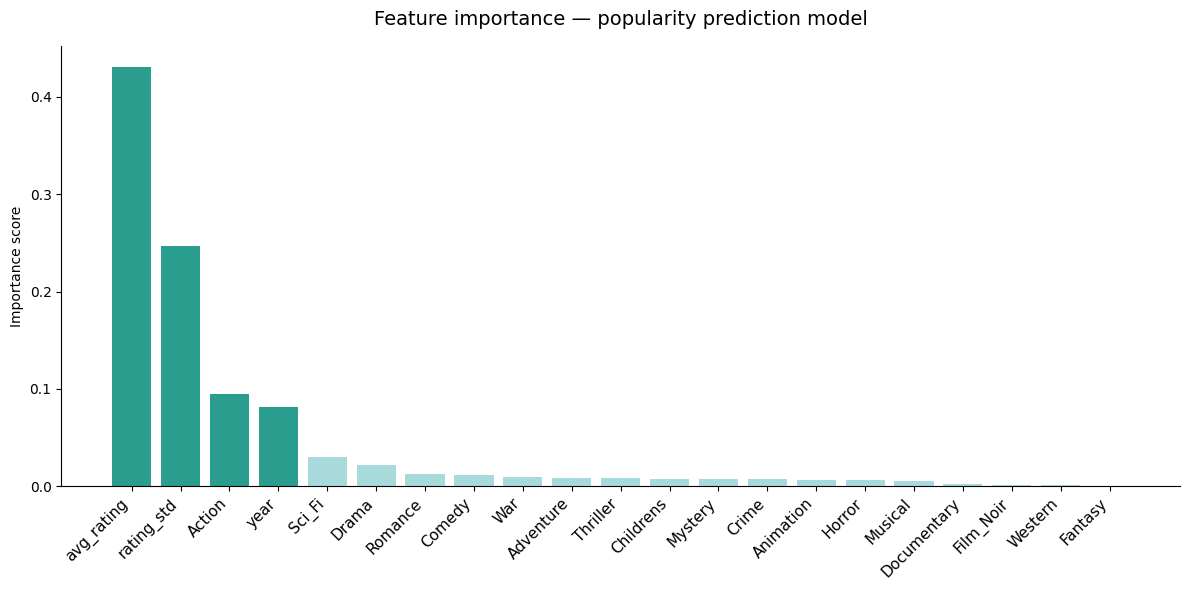

Top 5 most important features:
avg_rating    0.431000
rating_std    0.247261
Action        0.094572
year          0.081757
Sci_Fi        0.029459
dtype: float64


In [8]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(feature_importance.index,
               feature_importance.values,
               color=['#2a9d8f' if v > 0.05 else '#a8dadc' for v in feature_importance.values])
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title('Feature importance — popularity prediction model', fontsize=14, pad=15)
plt.ylabel('Importance score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
print(feature_importance.head())

In [9]:
# Save Random Forest model
with open('popularity_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save TF-IDF matrix and cosine similarity
with open('tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)

with open('cosine_sim.pkl', 'wb') as f:
    pickle.dump(cosine_sim, f)

# Save predicted ratings matrix
predicted_df.to_csv('predicted_ratings.csv')

# Save movie features
movie_features.to_csv('movie_features.csv', index=False)

# Save movies dataframe
movies.to_csv('movies_processed.csv', index=False)

# Save mood genre map
mood_genre_map = {
    'anxious':   ['Comedy', 'Animation', 'Childrens', 'Musical'],
    'sad':       ['Comedy', 'Romance', 'Animation'],
    'angry':     ['Documentary', 'Comedy', 'Musical'],
    'lonely':    ['Drama', 'Romance', 'Comedy'],
    'stressed':  ['Animation', 'Childrens', 'Musical', 'Comedy'],
    'happy':     ['Action', 'Adventure', 'Sci_Fi', 'Thriller'],
    'neutral':   ['Drama', 'Mystery', 'Thriller'],
    'depressed': ['Comedy', 'Animation', 'Musical', 'Childrens']
}

with open('mood_genre_map.json', 'w') as f:
    json.dump(mood_genre_map, f, indent=2)

print("=" * 50)
print("ALL MODELS SAVED SUCCESSFULLY")
print("=" * 50)
print("  popularity_model.pkl")
print("  tfidf_matrix.pkl")
print("  cosine_sim.pkl")
print("  predicted_ratings.csv")
print("  movie_features.csv")
print("  movies_processed.csv")
print("  mood_genre_map.json")
print("=" * 50)

ALL MODELS SAVED SUCCESSFULLY
  popularity_model.pkl
  tfidf_matrix.pkl
  cosine_sim.pkl
  predicted_ratings.csv
  movie_features.csv
  movies_processed.csv
  mood_genre_map.json


In [10]:
print("=" * 55)
print("     CINEHEALTH — MODELS NOTEBOOK SUMMARY")
print("=" * 55)
print(f"""
COLLABORATIVE FILTERING (SVD)
  Method         : Singular Value Decomposition
  Matrix shape   : 943 users × 1682 movies
  Latent factors : 50
  Status         : Working ✓

CONTENT-BASED FILTERING (TF-IDF)
  Method         : TF-IDF + Cosine Similarity
  Features       : 18 genre categories
  Matrix shape   : 1682 × 1682
  Status         : Working ✓

HYBRID RECOMMENDER
  Collab weight  : 60%
  Content weight : 40%
  Mood filters   : 8 emotional states
  Status         : Working ✓

POPULARITY PREDICTION (Random Forest)
  Model          : Random Forest (100 trees)
  RMSE           : 0.4029
  MAE            : 0.2298
  R² Score       : 0.4969
  Top feature    : avg_rating (43.1%)
  Status         : Working ✓

ALL MODELS SAVED — Ready for backend integration
""")
print("=" * 55)
print("Models notebook complete.")
print("=" * 55)

     CINEHEALTH — MODELS NOTEBOOK SUMMARY

COLLABORATIVE FILTERING (SVD)
  Method         : Singular Value Decomposition
  Matrix shape   : 943 users × 1682 movies
  Latent factors : 50
  Status         : Working ✓

CONTENT-BASED FILTERING (TF-IDF)
  Method         : TF-IDF + Cosine Similarity
  Features       : 18 genre categories
  Matrix shape   : 1682 × 1682
  Status         : Working ✓

HYBRID RECOMMENDER
  Collab weight  : 60%
  Content weight : 40%
  Mood filters   : 8 emotional states
  Status         : Working ✓

POPULARITY PREDICTION (Random Forest)
  Model          : Random Forest (100 trees)
  RMSE           : 0.4029
  MAE            : 0.2298
  R² Score       : 0.4969
  Top feature    : avg_rating (43.1%)
  Status         : Working ✓

ALL MODELS SAVED — Ready for backend integration

Models notebook complete.
